In [1]:
import pandas as pd
from helpers.wandb import WandbClient
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
client = WandbClient('advanced-ba')
runs = client.get_runs(filters = {"group": {"$in": ["evaluation", "orchestration"]}})


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/bertramhage/.netrc.


In [3]:
runs = runs[runs['cross_learning']==False]
len(runs)

22

In [4]:
metr_la_runs = runs[runs['dataset']=='METR-LA']
len(metr_la_runs)

4

In [5]:
baseline_runs = runs[(runs['wandb_tags'].apply(lambda x: 'baseline' in x)) & (runs['dataset']!='METR-LA')]
baseline_runs = baseline_runs[baseline_runs['evaluation_history_length_steps']>=288]
len(baseline_runs)

4

In [6]:
holdout_runs = runs[(runs['wandb_tags'].apply(lambda x: 'station_set_holdout' in x)) & (runs['dataset']!='METR-LA')]
len(holdout_runs)

2

In [7]:
holdout_runs[['wandb_run_name', 'orchestration_short_context_length_steps', 'eval/h60_RMSE_running_avg']].iloc[0]

wandb_run_name                              rq2_station_gen_28258867_eval_holdout
orchestration_short_context_length_steps                                    288.0
eval/h60_RMSE_running_avg                                                4.363721
Name: 19, dtype: object

In [8]:
adapted_runs = runs[(runs['wandb_tags'].apply(lambda x: 'fullscale' in x)) & (runs['dataset']!='METR-LA')\
    & (runs['orchestration_short_context_length_steps']==288)]
len(adapted_runs)

8

In [9]:
baseline_runs[['wandb_run_name', 'evaluation_history_length_steps']]

,wandb_run_name,evaluation_history_length_steps
4,baseline_subset40_28188664_ctx_24h,288.0
6,baseline_subset40_28188664_ctx_2d,576.0
8,baseline_subset40_28188664_ctx_7d,2016.0
10,baseline_subset40_28188664_ctx_14d,4032.0


In [10]:
runs_shortlist = [
    'eval_28224230', # 'checkpoints/final_7d_t/best_hypernet.pt'
    'eval_28227813', # 'checkpoints/final_7d_g/best_hypernet.pt'
    'eval_28229214', # 'checkpoints/final_14d_t/best_hypernet.pt'
    'eval_28230928'# 'checkpoints/final_14d_g/best_hypernet.pt'
]
adapted_runs = adapted_runs[adapted_runs['wandb_run_name'].isin(runs_shortlist)]
adapted_runs[['wandb_run_name', 'orchestration_checkpoint_path', 'orchestration_long_history_length_steps', 'orchestration_short_context_length_steps', 'eval/h60_RMSE_running_avg']]

,wandb_run_name,orchestration_checkpoint_path,orchestration_long_history_length_steps,orchestration_short_context_length_steps,eval/h60_RMSE_running_avg
14,eval_28224230,checkpoints/final_7d_t/best_hypernet.pt,2016.0,288.0,4.336257
15,eval_28227813,checkpoints/final_7d_g/best_hypernet.pt,2016.0,288.0,4.266473
16,eval_28229214,checkpoints/final_14d_t/best_hypernet.pt,4032.0,288.0,4.334495
17,eval_28230928,checkpoints/final_14d_g/best_hypernet.pt,4032.0,288.0,4.289013


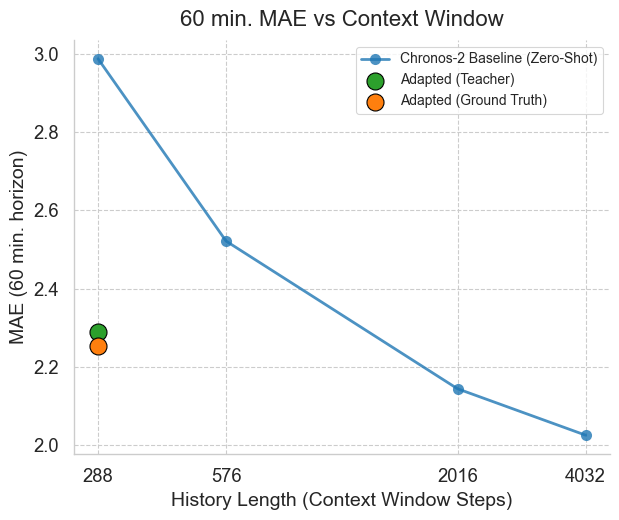

In [11]:
# Set academic style
plt.style.use('seaborn-v0_8-paper') 
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

# Define data_baseline from the prior filtered baseline_runs
data_baseline = baseline_runs.sort_values('evaluation_history_length_steps')

METRIC = 'eval/h60_MAE_running_avg'

fig, ax = plt.subplots(figsize=(6, 5))

# Plot Baseline
ax.plot(data_baseline['evaluation_history_length_steps'], data_baseline[METRIC], 
        label='Chronos-2 Baseline (Zero-Shot)', 
        color='#1f77b4', marker='o', linewidth=2, markersize=8, alpha=0.8)

# Plot Adapted versions (Points)
teacher_data = adapted_runs[adapted_runs['wandb_run_name'] == 'eval_28224230']
ax.scatter(teacher_data['orchestration_short_context_length_steps'], teacher_data[METRIC], 
           label='Adapted (Teacher)', color='#2ca02c', s=150, edgecolors='black', zorder=5)

gt_data = adapted_runs[adapted_runs['wandb_run_name'] == 'eval_28227813']
ax.scatter(gt_data['orchestration_short_context_length_steps'], gt_data[METRIC], 
           label='Adapted (Ground Truth)', color='#ff7f0e', s=150, edgecolors='black', zorder=5)

# Formatting
ax.set_xlabel('History Length (Context Window Steps)', fontsize=14)
ax.set_ylabel('MAE (60 min. horizon)', fontsize=14)
ax.set_title('60 min. MAE vs Context Window', fontsize=16, pad=10)
ax.set_xscale('log') # Log scale emphasizes the efficiency gain
ax.set_xticks(data_baseline['evaluation_history_length_steps'].dropna().astype(int).tolist())
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.legend(frameon=True, loc='upper right', fontsize=10)
sns.despine()

plt.tight_layout(pad=0)
plt.savefig('figures/performance_compression_h.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [16]:
naming_dict = {
    'eval_28224230': 'Adapted 2016 steps (Teacher)',
    'eval_28227813': 'Adapted 2016 steps (Ground Truth)',
    'eval_28229214': 'Adapted 4032 steps (Teacher)',
    'eval_28230928': 'Adapted 4032 steps (Ground Truth)'
}

summary_data = []

# Add baseline runs
for _, row in data_baseline.iterrows():
    summary_data.append({
        'Model': f"Baseline {int(row['evaluation_history_length_steps'])} steps",
        'h15 MAE': row['eval/h15_MAE_running_avg'],
        'h15 Coverage': row['eval/h15_COVERAGE_running_avg'],
        'h30 MAE': row['eval/h30_MAE_running_avg'],
        'h30 Coverage': row['eval/h30_COVERAGE_running_avg'],
        'h60 MAE': row['eval/h60_MAE_running_avg'],
        'h60 Coverage': row['eval/h60_COVERAGE_running_avg']
    })

# Add adapted runs
for run_id, model_name in naming_dict.items():
    row = adapted_runs[adapted_runs['wandb_run_name'] == run_id].iloc[0]
    summary_data.append({
        'Model': model_name,
        'h15 MAE': row['eval/h15_MAE_running_avg'],
        'h15 Coverage': row['eval/h15_COVERAGE_running_avg'],
        'h30 MAE': row['eval/h30_MAE_running_avg'],
        'h30 Coverage': row['eval/h30_COVERAGE_running_avg'],
        'h60 MAE': row['eval/h60_MAE_running_avg'],
        'h60 Coverage': row['eval/h60_COVERAGE_running_avg']
    })

summary_table = pd.DataFrame(summary_data)
with open("../assets/tables/results_table.md", "w") as f:
    f.write(summary_table.round(3).to_markdown(index=False))
summary_table.round(3)


,Model,h15 MAE,h15 Coverage,h30 MAE,h30 Coverage,h60 MAE,h60 Coverage
0,Baseline 288 steps,1.766,0.758,2.266,0.758,2.987,0.755
1,Baseline 576 steps,1.650,0.753,2.040,0.755,2.521,0.756
2,Baseline 2016 steps,1.542,0.758,1.835,0.765,2.144,0.771
3,Baseline 4032 steps,1.506,0.754,1.769,0.763,2.026,0.771
4,Adapted 2016 steps (Teacher),1.563,0.746,1.905,0.748,2.288,0.753
5,Adapted 2016 steps (Ground Truth),1.562,0.802,1.893,0.791,2.254,0.784
6,Adapted 4032 steps (Teacher),1.571,0.734,1.919,0.738,2.296,0.747
7,Adapted 4032 steps (Ground Truth),1.563,0.809,1.893,0.811,2.266,0.812


In [20]:
# Select the holdout run and adapted 2016/4032 runs, plus baselines for 2d and 7d
holdout_row = runs[runs['wandb_run_name'] == 'rq2_station_gen_28258867_eval_holdout'].iloc[0]
adapted_teacher_row = runs[runs['wandb_run_name'] == 'eval_28224230'].iloc[0]
adapted_gt_row = runs[runs['wandb_run_name'] == 'eval_28227813'].iloc[0]
adapted_teacher_4032_row = runs[runs['wandb_run_name'] == 'eval_28229214'].iloc[0]
adapted_gt_4032_row = runs[runs['wandb_run_name'] == 'eval_28230928'].iloc[0]

# Baseline rows for 2d and 7d (history length 576 and 2016)
baseline_2d_row = runs[(runs['wandb_tags'].apply(lambda x: 'baseline' in x)) & (runs['evaluation_history_length_steps'] == 576)].iloc[0]
baseline_7d_row = runs[(runs['wandb_tags'].apply(lambda x: 'baseline' in x)) & (runs['evaluation_history_length_steps'] == 2016)].iloc[0]

comparison = pd.DataFrame([
    {
        'Model': 'Holdout 2016 steps (Teacher)',
        'h15 MAE': holdout_row['eval/h15_MAE_running_avg'],
        'h15 Coverage': holdout_row['eval/h15_COVERAGE_running_avg'],
        'h30 MAE': holdout_row['eval/h30_MAE_running_avg'],
        'h30 Coverage': holdout_row['eval/h30_COVERAGE_running_avg'],
        'h60 MAE': holdout_row['eval/h60_MAE_running_avg'],
        'h60 Coverage': holdout_row['eval/h60_COVERAGE_running_avg']
    },
    {
        'Model': 'Baseline 2d',
        'h15 MAE': baseline_2d_row['eval/h15_MAE_running_avg'],
        'h15 Coverage': baseline_2d_row['eval/h15_COVERAGE_running_avg'],
        'h30 MAE': baseline_2d_row['eval/h30_MAE_running_avg'],
        'h30 Coverage': baseline_2d_row['eval/h30_COVERAGE_running_avg'],
        'h60 MAE': baseline_2d_row['eval/h60_MAE_running_avg'],
        'h60 Coverage': baseline_2d_row['eval/h60_COVERAGE_running_avg']
    },
    {
        'Model': 'Baseline 7d',
        'h15 MAE': baseline_7d_row['eval/h15_MAE_running_avg'],
        'h15 Coverage': baseline_7d_row['eval/h15_COVERAGE_running_avg'],
        'h30 MAE': baseline_7d_row['eval/h30_MAE_running_avg'],
        'h30 Coverage': baseline_7d_row['eval/h30_COVERAGE_running_avg'],
        'h60 MAE': baseline_7d_row['eval/h60_MAE_running_avg'],
        'h60 Coverage': baseline_7d_row['eval/h60_COVERAGE_running_avg']
    },
    {
        'Model': 'Adapted 2016 steps (Teacher)',
        'h15 MAE': adapted_teacher_row['eval/h15_MAE_running_avg'],
        'h15 Coverage': adapted_teacher_row['eval/h15_COVERAGE_running_avg'],
        'h30 MAE': adapted_teacher_row['eval/h30_MAE_running_avg'],
        'h30 Coverage': adapted_teacher_row['eval/h30_COVERAGE_running_avg'],
        'h60 MAE': adapted_teacher_row['eval/h60_MAE_running_avg'],
        'h60 Coverage': adapted_teacher_row['eval/h60_COVERAGE_running_avg']
    },
    {
        'Model': 'Adapted 2016 steps (Ground Truth)',
        'h15 MAE': adapted_gt_row['eval/h15_MAE_running_avg'],
        'h15 Coverage': adapted_gt_row['eval/h15_COVERAGE_running_avg'],
        'h30 MAE': adapted_gt_row['eval/h30_MAE_running_avg'],
        'h30 Coverage': adapted_gt_row['eval/h30_COVERAGE_running_avg'],
        'h60 MAE': adapted_gt_row['eval/h60_MAE_running_avg'],
        'h60 Coverage': adapted_gt_row['eval/h60_COVERAGE_running_avg']
    },
])

comparison.round(3)
with open("../assets/tables/holdout_comparison_table.md", "w") as f:
    f.write(comparison.round(3).to_markdown(index=False))

In [24]:
# Prepare summary for METR-LA runs: 3 baselines and 1 adapted, same metrics as before

# Identify METR-LA baseline runs (by history length)
metr_la_baselines = metr_la_runs.sort_values('evaluation_history_length_steps')
metr_la_adapted = metr_la_runs[metr_la_runs['wandb_tags'].apply(lambda x: 'adapted' in x if isinstance(x, list) else False)]

metr_la_summary = []

# Add baselines
for _, row in metr_la_baselines.iterrows():
    evaluation_steps = row['evaluation_history_length_steps'] if not pd.isna(row['evaluation_history_length_steps']) else 0
    metr_la_summary.append({
        'Model': f"Baseline {int(evaluation_steps)} steps",
        'h15 MAE': row['eval/h15_MAE_running_avg'],
        'h15 Coverage': row['eval/h15_COVERAGE_running_avg'],
        'h30 MAE': row['eval/h30_MAE_running_avg'],
        'h30 Coverage': row['eval/h30_COVERAGE_running_avg'],
        'h60 MAE': row['eval/h60_MAE_running_avg'],
        'h60 Coverage': row['eval/h60_COVERAGE_running_avg']
    })

# Add adapted run (if present)
if not metr_la_adapted.empty:
    row = metr_la_adapted.iloc[0]
    metr_la_summary.append({
        'Model': 'Adapted (PEMS-BAY Hypernet)',
        'h15 MAE': row['eval/h15_MAE_running_avg'],
        'h15 Coverage': row['eval/h15_COVERAGE_running_avg'],
        'h30 MAE': row['eval/h30_MAE_running_avg'],
        'h30 Coverage': row['eval/h30_COVERAGE_running_avg'],
        'h60 MAE': row['eval/h60_MAE_running_avg'],
        'h60 Coverage': row['eval/h60_COVERAGE_running_avg']
    })

metr_la_summary_table = pd.DataFrame(metr_la_summary)
with open("../assets/tables/metr_la_results_table.md", "w") as f:
    f.write(metr_la_summary_table.round(3).to_markdown(index=False))
metr_la_summary_table.round(3)

,Model,h15 MAE,h15 Coverage,h30 MAE,h30 Coverage,h60 MAE,h60 Coverage
0,Baseline 288 steps,3.594,0.766,4.456,0.751,5.807,0.718
1,Baseline 576 steps,3.572,0.757,4.412,0.745,5.600,0.715
2,Baseline 2016 steps,3.372,0.746,4.058,0.743,4.895,0.712
3,Baseline 0 steps,3.415,0.758,4.142,0.749,5.136,0.724
4,Adapted (PEMS-BAY Hypernet),3.415,0.758,4.142,0.749,5.136,0.724
